# Part 1: Data Acquisition, Cleaning, and Exploratory Data Analysis (EDA)

## Objective

The goal of this part is to load the raw dataset, inspect its structure, identify and handle missing values, detect duplicate records, correct data types, analyze descriptive statistics, detect outliers, visualize the data, study correlations, and finally prepare a clean dataset for machine learning in the next parts.

### Dataset Chosen

**House Prices - Advanced Regression Techniques (Ames Housing Dataset)**

### Why this dataset?

This dataset was selected because it satisfies all the assignment requirements:

- More than **500 rows** (1460 observations)
- More than **5 numeric columns**
- More than **2 categorical columns**
- Contains a continuous target variable (**SalePrice**) suitable for regression
- The target can later be converted into a binary class (High Price vs Low Price) for classification in Part 2
- Includes missing values, categorical features, skewed distributions, and outliers, making it suitable for data cleaning and exploratory data analysis.

In [91]:
# Install Required Libraries (if needed)

!pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Better looking plots
plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

print("\nAll Libraries imported successfully.")



All Libraries imported successfully.


# Step 1: Load the Dataset

In this step, the raw CSV dataset is loaded into a pandas DataFrame using `pd.read_csv()`.

After loading the dataset, we perform an initial inspection by:

- Displaying the first five rows
- Checking the dataset dimensions
- Examining the data types of all columns

This provides an overview of the dataset before beginning the cleaning process.

In [92]:
from google.colab import files

files.upload()

# Load Dataset
df = pd.read_csv("train.csv")

print("\nDataset loaded successfully!!.")

Saving train.csv to train (8).csv

Dataset loaded successfully!!.


In [93]:
# Initial Dataset Inspection / Basic Information
# ============================================================

print("="*70)
print("First Five Rows")
print("="*70)

display(df.head())

print("\n")

print("="*70)
print("Dataset Shape")
print("="*70)

print(df.shape)

print("\n")

print("="*70)
print("Column Data Types")
print("="*70)

print(df.dtypes)

First Five Rows


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000




Dataset Shape
(1460, 81)


Column Data Types
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
Tot

# Step 2: Missing Value Analysis

Real-world datasets often contain missing values that must be handled before building machine learning models.

In this step, we will:

- Calculate the total number of missing values in each column.
- Calculate the percentage of missing values.
- Identify columns with more than **20% missing values**.
- Impute missing values in numeric columns having less than **20% missing values** using the **median**.

### Why Median Instead of Mean?

The median is less sensitive to extreme values (outliers) than the mean. Since many housing-related features are expected to have skewed distributions and outliers, median imputation provides a more robust estimate of the central tendency.

In [94]:
# Missing (Null) Value Analysis
# ============================================================

# Count missing values
null_count = df.isnull().sum()

# Percentage of missing values
null_percentage = (null_count / len(df)) * 100

# Create summary table
missing_df = pd.DataFrame({
    "Missing Values": null_count,
    "Missing Percentage": null_percentage
})

# Display only columns having missing values
missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df = missing_df.sort_values(by="Missing Percentage", ascending=False)

print("="*70)
print("Missing Value Summary")
print("="*70)

display(missing_df)

Missing Value Summary


,Missing Values,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [95]:
# Fill Missing Values in Numeric Columns (<20% Missing)
# ============================================================

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    missing_percent = (df[col].isnull().sum() / len(df)) * 100

    if 0 < missing_percent < 20:
        df[col].fillna(df[col].median(), inplace=True)

print("Median imputation completed for numeric columns with less than 20% missing values.")

Median imputation completed for numeric columns with less than 20% missing values.


/tmp/ipykernel_1264/3676841416.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [96]:
# Verify Remaining Missing Values
# ============================================================

remaining_nulls = df.isnull().sum()

remaining_nulls = remaining_nulls[remaining_nulls > 0]

print("="*70)
print("Remaining Columns with Missing Values")
print("="*70)

display(remaining_nulls)

Remaining Columns with Missing Values


,0
Alley,1369
MasVnrType,872
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1
FireplaceQu,690
GarageType,81


# Step 3: Duplicate Detection and Removal

Duplicate records can introduce bias into data analysis and machine learning models.

In this step, we will:

- Count the number of duplicate rows.
- Remove duplicate records if any exist.
- Compare the dataset shape before and after removal.
- Verify whether removing duplicates changes the missing-value percentages.

In [97]:
# Duplicate Detection and Removal
# ============================================================

# Dataset shape before removing duplicates
before_shape = df.shape

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("="*70)
print("Duplicate Rows")
print("="*70)
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates
df = df.drop_duplicates()

# Dataset shape after removing duplicates
after_shape = df.shape

print("\nDataset Shape Before:", before_shape)
print("Dataset Shape After :", after_shape)

print(f"\nRows Removed: {before_shape[0] - after_shape[0]}")

Duplicate Rows
Number of duplicate rows: 0

Dataset Shape Before: (1460, 81)
Dataset Shape After : (1460, 81)

Rows Removed: 0


In [98]:
# Missing Values After Removing Duplicates
# ============================================================

null_after = (df.isnull().sum() / len(df)) * 100

print("="*70)
print("Missing Value Percentage After Removing Duplicates")
print("="*70)

display(
    null_after[null_after > 0]
    .sort_values(ascending=False)
    .to_frame(name="Missing Percentage")
)

Missing Value Percentage After Removing Duplicates


,Missing Percentage
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
GarageFinish,5.547945
GarageQual,5.547945
GarageType,5.547945
GarageCond,5.547945


# Step 4: Data Type Correction and Memory Optimization

Some columns may not have the most appropriate data type for analysis.

In this step, we will:

- Measure the dataset's memory usage.
- Convert `MSSubClass` from integer to the `category` data type because it represents discrete classes rather than continuous numerical values.
- Convert `Neighborhood` from `object` to `category` since it contains repeated string values.
- Compare memory usage before and after the conversion.

In [99]:
# Memory Usage Before Conversion
# ============================================================

memory_before = df.memory_usage(deep=True).sum()

print("="*70)
print("Memory Usage Before Conversion")
print("="*70)

print(f"{memory_before:,} bytes")

Memory Usage Before Conversion
3,600,842 bytes


In [100]:
# Data Type Conversion
# ============================================================

# Convert numerical category to categorical type
df["MSSubClass"] = df["MSSubClass"].astype("category")

# Convert repetitive string column to category
df["Neighborhood"] = df["Neighborhood"].astype("category")

print("Data type conversion completed successfully.")

Data type conversion completed successfully.


In [101]:
# Memory Usage After Conversion
# ============================================================

memory_after = df.memory_usage(deep=True).sum()

print("="*70)
print("Memory Usage After Conversion")
print("="*70)

print(f"{memory_after:,} bytes")

print("\nMemory Saved:", memory_before - memory_after, "bytes")

Memory Usage After Conversion
3,513,683 bytes

Memory Saved: 87159 bytes


In [102]:
 # Verify Updated Data Types
# ============================================================

print("="*70)
print("Updated Data Types")
print("="*70)

print(df[["MSSubClass", "Neighborhood"]].dtypes)

Updated Data Types
MSSubClass      category
Neighborhood    category
dtype: object


# Step 5: Descriptive Statistics and Skewness Analysis

Descriptive statistics provide an overview of the numerical features in the dataset, including measures such as mean, standard deviation, minimum, maximum, and quartiles.

Skewness measures the asymmetry of a distribution:

- **Positive skewness:** The distribution has a long right tail caused by a few unusually large values.
- **Negative skewness:** The distribution has a long left tail caused by a few unusually small values.

Highly skewed variables are more sensitive to outliers, making the **median** a more reliable measure of central tendency than the mean for imputing missing values.

In [103]:
# Descriptive Statistics

print("=" * 70)
print("Descriptive Statistics")
print("=" * 70)

display(df.describe())

Descriptive Statistics


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.589041,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,23.997022,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1962.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [104]:
# Skewness Analysis

# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate skewness
skewness = numeric_df.skew()

# Convert to DataFrame
skew_df = pd.DataFrame({
    "Skewness": skewness,
    "Absolute Skewness": skewness.abs()
})

# Sort by absolute skewness
skew_df = skew_df.sort_values(
    by="Absolute Skewness",
    ascending=False
)

print("=" * 70)
print("Skewness of Numeric Columns")
print("=" * 70)

display(skew_df)

print("\nMost Skewed Column:", skew_df.index[0])
print("Skewness Value:", round(skew_df.iloc[0]["Skewness"], 4))

Skewness of Numeric Columns


,Skewness,Absolute Skewness
MiscVal,24.476794,24.476794
PoolArea,14.828374,14.828374
LotArea,12.207688,12.207688
3SsnPorch,10.304342,10.304342
LowQualFinSF,9.011341,9.011341
KitchenAbvGr,4.488397,4.488397
BsmtFinSF2,4.255261,4.255261
ScreenPorch,4.122214,4.122214
BsmtHalfBath,4.103403,4.103403
EnclosedPorch,3.089872,3.089872



Most Skewed Column: MiscVal
Skewness Value: 24.4768


In [105]:
# Top 10 Most Skewed Columns

display(skew_df.head(10))

,Skewness,Absolute Skewness
MiscVal,24.476794,24.476794
PoolArea,14.828374,14.828374
LotArea,12.207688,12.207688
3SsnPorch,10.304342,10.304342
LowQualFinSF,9.011341,9.011341
KitchenAbvGr,4.488397,4.488397
BsmtFinSF2,4.255261,4.255261
ScreenPorch,4.122214,4.122214
BsmtHalfBath,4.103403,4.103403
EnclosedPorch,3.089872,3.089872


# Step 6: Outlier Detection Using the IQR Method

Outliers are observations that lie significantly outside the normal range of a variable.

The Interquartile Range (IQR) method identifies outliers using:

- Q1 (25th percentile)
- Q3 (75th percentile)
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

In this analysis, outliers are identified but **not removed**. They will be evaluated during model development in Part 2, where techniques such as robust models or feature transformations may be considered.

In [106]:
# ============================================================
# IQR Outlier Detection
# ============================================================

columns = ["SalePrice", "GrLivArea"]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("="*70)
    print(f"Column : {col}")
    print("="*70)

    print(f"Q1          : {Q1}")
    print(f"Q3          : {Q3}")
    print(f"IQR         : {IQR}")
    print(f"Lower Bound : {lower}")
    print(f"Upper Bound : {upper}")
    print(f"Outliers    : {len(outliers)}")

Column : SalePrice
Q1          : 129975.0
Q3          : 214000.0
IQR         : 84025.0
Lower Bound : 3937.5
Upper Bound : 340037.5
Outliers    : 61
Column : GrLivArea
Q1          : 1129.5
Q3          : 1776.75
IQR         : 647.25
Lower Bound : 158.625
Upper Bound : 2747.625
Outliers    : 31


# Step 7: Data Visualization

Data visualization helps us understand patterns, trends, distributions, and relationships among variables.

The following visualizations are included:

1. Line Plot
2. Bar Chart
3. Histogram
4. Scatter Plot
5. Box Plot

Each visualization includes appropriate titles and axis labels for interpretation.

## 7.1 Line Plot

This plot shows how the `SalePrice` values change across the dataset records.

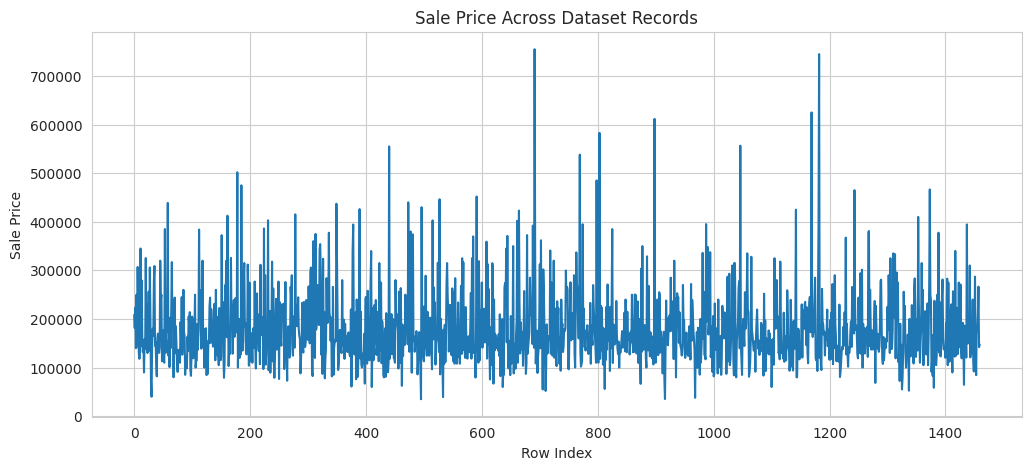

In [107]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["SalePrice"])

plt.title("Sale Price Across Dataset Records")

plt.xlabel("Row Index")

plt.ylabel("Sale Price")

plt.show()

## 7.2 Bar Chart

This chart compares the average sale price across different neighborhoods.

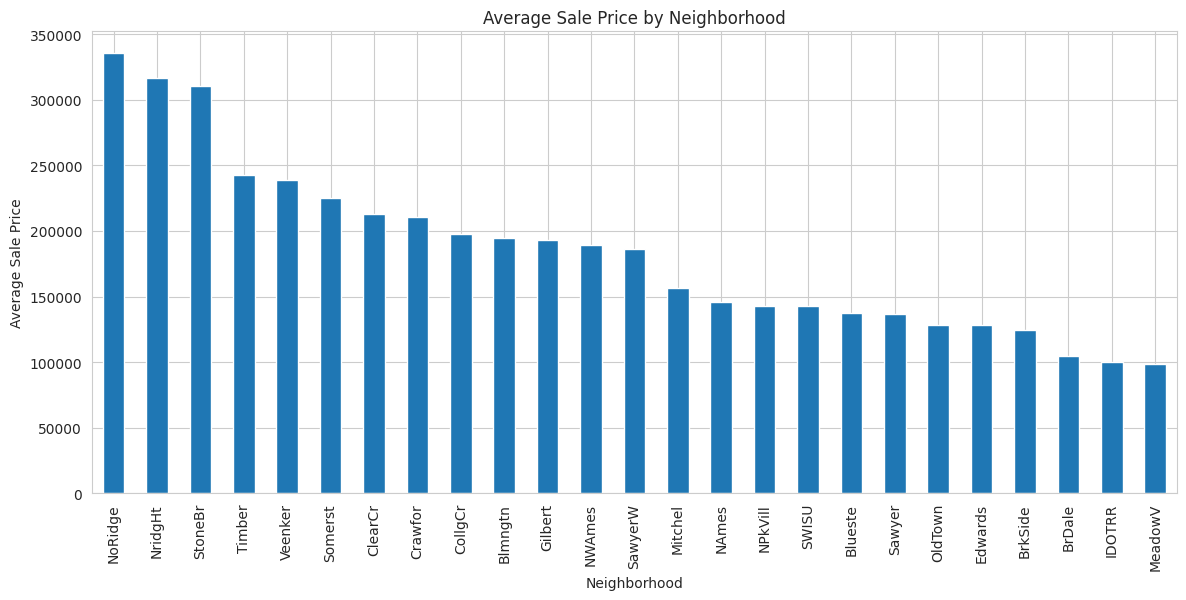

In [108]:
avg_price = df.groupby("Neighborhood", observed=False)["SalePrice"].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))

avg_price.plot(kind="bar")

plt.title("Average Sale Price by Neighborhood")

plt.xlabel("Neighborhood")

plt.ylabel("Average Sale Price")

plt.xticks(rotation=90)

plt.show()

## 7.3 Histogram

This histogram displays the distribution of the most skewed numerical feature (`MiscVal`).

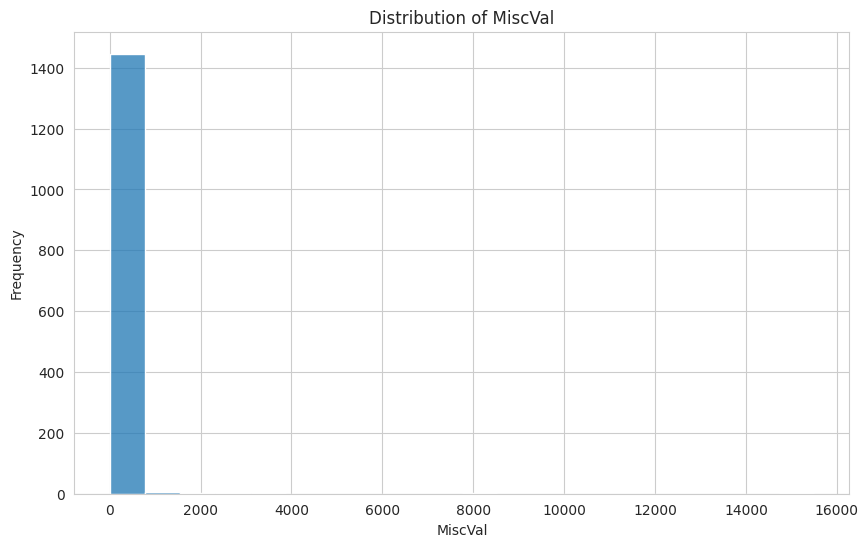

In [109]:
plt.figure(figsize=(10,6))

sns.histplot(df["MiscVal"], bins=20)

plt.title("Distribution of MiscVal")

plt.xlabel("MiscVal")

plt.ylabel("Frequency")

plt.show()

## 7.4 Scatter Plot

This scatter plot examines the relationship between above-ground living area and sale price.

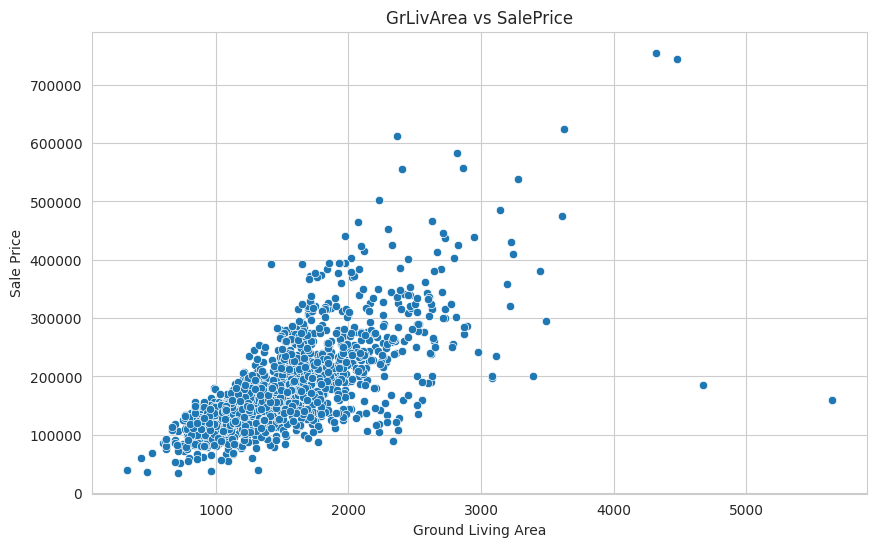

In [110]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="GrLivArea",
                y="SalePrice")

plt.title("GrLivArea vs SalePrice")

plt.xlabel("Ground Living Area")

plt.ylabel("Sale Price")

plt.show()

## 7.5 Box Plot

The box plot compares the distribution of sale prices across neighborhoods.

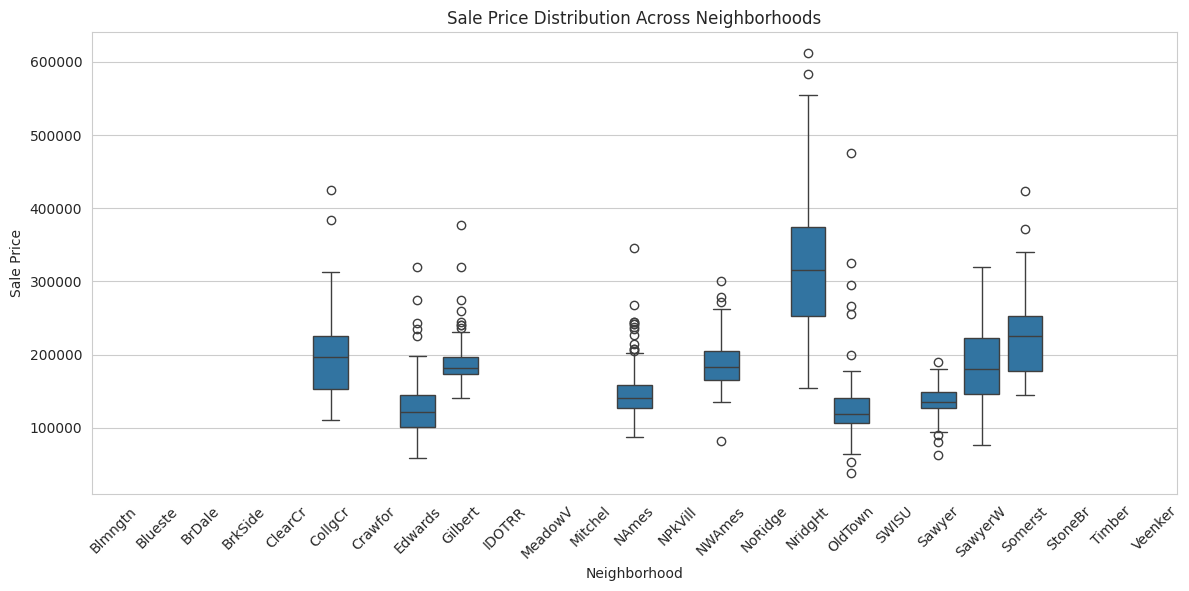

In [111]:
top10 = df["Neighborhood"].value_counts().head(10).index

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df[df["Neighborhood"].isin(top10)],
    x="Neighborhood",
    y="SalePrice"
)

plt.xticks(rotation=45)

plt.title("Sale Price Distribution Across Neighborhoods")

plt.xlabel("Neighborhood")

plt.ylabel("Sale Price")

plt.show()

# Step 8: Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables.

In this step, we:
- Compute the Pearson correlation matrix for all numerical columns.
- Visualize it using a heatmap.
- Identify the pair of variables with the highest absolute correlation (excluding self-correlation).
- Interpret whether the relationship implies causation or may be explained by other factors.

In [112]:
# Pearson Correlation Matrix
# ============================================================

numeric_df = df.select_dtypes(include=["int64", "float64"])

pearson_corr = numeric_df.corr()

print("=" * 70)
print("Pearson Correlation Matrix")
print("=" * 70)

display(pearson_corr)

Pearson Correlation Matrix


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,-0.009921,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.051071,-0.005024,-0.005968,-0.007940,-0.015415,0.010496,0.005590,-0.044230,0.008273,0.002289,-0.020155,0.005587,0.006784,0.037719,0.002951,0.027239,-0.019772,-0.000122,0.016570,0.017634,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
LotFrontage,-0.009921,1.000000,0.304522,0.234812,-0.053281,0.116685,0.083348,0.178469,0.214367,0.042463,0.124098,0.363472,0.413773,0.072388,0.037469,0.368007,0.090343,-0.006979,0.180534,0.047222,0.236840,-0.004905,0.320518,0.233221,0.062996,0.269539,0.323511,0.075542,0.137014,0.010287,0.061945,0.037655,0.180819,-0.000255,0.010451,0.006380,0.334771
LotArea,-0.033226,0.304522,1.000000,0.105806,-0.005636,0.014228,0.013788,0.103321,0.214103,0.111170,-0.002618,0.260833,0.299475,0.050986,0.004779,0.263116,0.158155,0.048046,0.126031,0.014259,0.119690,-0.017784,0.190015,0.271364,-0.025865,0.154871,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.234812,0.105806,1.000000,-0.091932,0.572323,0.550684,0.407252,0.239666,-0.059119,0.308159,0.537808,0.476224,0.295493,-0.030429,0.593007,0.111098,-0.040150,0.550600,0.273458,0.101676,-0.183882,0.427452,0.396765,0.514231,0.600671,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.053281,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.125694,-0.046231,0.040229,-0.136841,-0.171098,-0.144203,0.028942,0.025494,-0.079686,-0.054942,0.117821,-0.194149,-0.060769,0.012980,-0.087001,-0.057583,-0.023820,-0.306276,-0.185758,-0.151521,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.116685,0.014228,0.572323,-0.375983,1.000000,0.592855,0.311600,0.249503,-0.049107,0.149040,0.391452,0.281986,0.010308,-0.183784,0.199010,0.187599,-0.038162,0.468271,0.242656,-0.070651,-0.174800,0.095589,0.147716,0.777182,0.537850,0.478954,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.083348,0.013788,0.550684,0.073741,0.592855,1.000000,0.176529,0.128451,-0.067759,0.181133,0.291066,0.240379,0.140024,-0.062419,0.287389,0.119470,-0.012337,0.439046,0.183331,-0.040581,-0.149598,0.191740,0.112581,0.616444,0.420622,0.371600,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.051071,0.178469,0.103321,0.407252,-0.125694,0.311600,0.176529,1.000000,0.261256,-0.071330,0.113862,0.360067,0.339850,0.173800,-0.068628,0.388052,0.083010,0.027403,0.272999,0.199108,0.102775,-0.038450,0.279568,0.247015,0.244444,0.361945,0.370884,0.159991,0.122528,-0.109907,0.019144,0.062248,0.011928,-0.029512,-0.006723,-0.008317,0.472614
BsmtFinSF1,-0.005024,0.214367,0.214103,0.239666,-0.046231,0.249503,0.128451,0.261256,1.000000,-0.050117,-0.495251,0.522396,0.445863,-0.137079,-0.064503,0.208171,0.649212,0.067418,0.058543,0.004262,-0.107355,-0.081007,0.044316,0.260011,0.148782,0.224054,0.296970,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.005968,0.042463,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.071330,-0.050117,1.000000,-0.209294,0.104810,0.097117,-0.099260,0.014807,-0.009640,0.158678,0.070948,-0.076444,-0.032148,-0.015728,-0.040751,-0.035227,0.046921,-0.087684,-0.038264,-0.018227,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


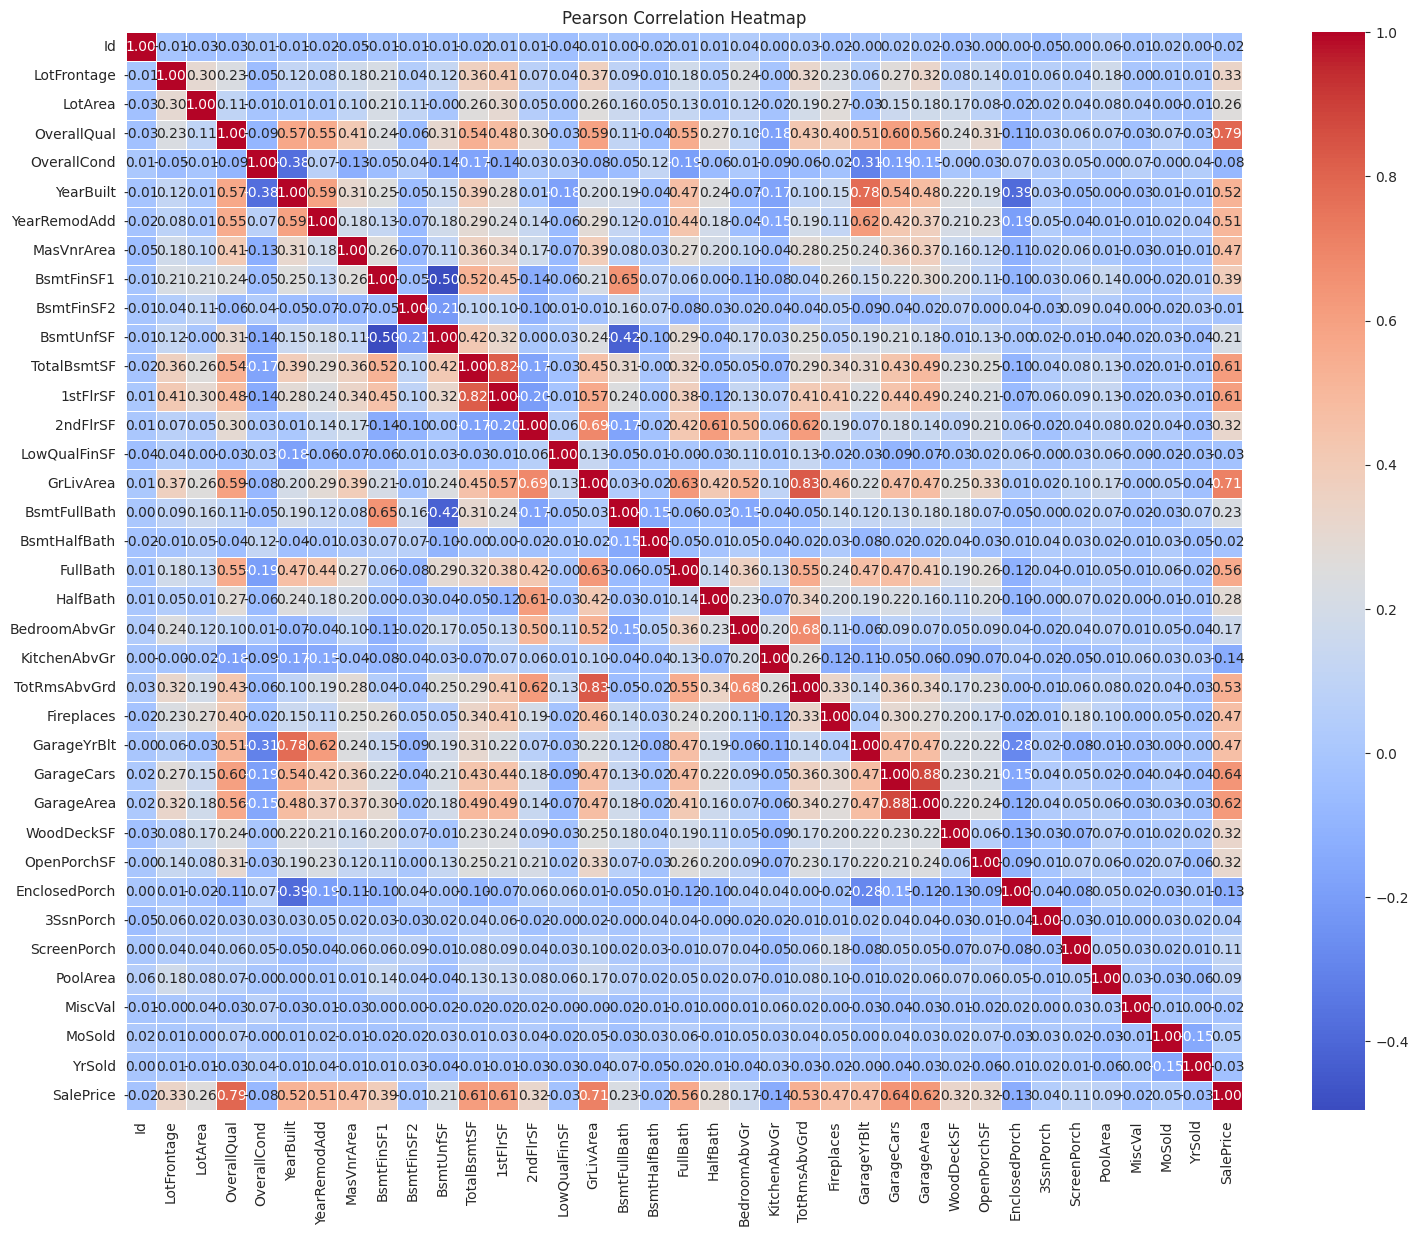

In [113]:
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(18, 14))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")

plt.show()

In [114]:
# Highest Absolute Correlation Pair (excluding diagonal)
# ============================================================

corr_matrix = pearson_corr.abs()

# Remove self-correlation
np.fill_diagonal(corr_matrix.values, 0)

# Find maximum correlation pair
max_pair = corr_matrix.unstack().idxmax()
max_value = corr_matrix.unstack().max()

print("=" * 70)
print("Highest Correlated Pair")
print("=" * 70)

print(f"Variables : {max_pair[0]}  &  {max_pair[1]}")
print(f"Correlation: {max_value:.4f}")

Highest Correlated Pair
Variables : GarageCars  &  GarageArea
Correlation: 0.8825


# Step 9(a): Mean vs Median Comparison

For the two most skewed numerical features, the mean and median are compared before imputation.

Since highly skewed distributions are influenced by extreme values, the median is generally a more representative measure of central tendency than the mean.

In [115]:
# Mean vs Median Comparison
# ============================================================

top_two = ["MiscVal", "PoolArea"]

comparison = pd.DataFrame(columns=["Mean", "Median"])

for col in top_two:
    comparison.loc[col] = [df[col].mean(), df[col].median()]

print("=" * 70)
print("Mean vs Median")
print("=" * 70)

display(comparison)

Mean vs Median


,Mean,Median
MiscVal,43.489041,0.0
PoolArea,2.758904,0.0


In [116]:
# Impute Remaining Missing Values (if any)
# ============================================================

for col in top_two:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(df[top_two].isnull().sum())

MiscVal     0
PoolArea    0
dtype: int64


# Step 9(b): Spearman Rank Correlation

Pearson correlation measures linear relationships, while Spearman correlation measures monotonic relationships based on ranked values.

Comparing both helps identify variable pairs that have a consistent but non-linear relationship.

In [117]:
# Spearman Correlation Matrix
# ============================================================

spearman_corr = numeric_df.corr(method="spearman")

print("="*70)
print("Spearman Correlation Matrix")
print("="*70)

display(spearman_corr)

Spearman Correlation Matrix


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,-0.032951,-0.005364,-0.028771,0.003622,-0.005130,-0.011680,-0.036547,-0.013038,-0.006736,-0.009509,-0.033187,-0.000616,0.009455,-0.028463,0.002812,0.004662,-0.021475,0.007269,0.002564,0.041650,0.007574,0.025888,-0.013644,-0.003242,0.013301,0.006505,-0.043239,-0.003225,-0.006758,-0.036706,0.005962,0.055555,-0.043383,0.019018,0.001526,-0.018546
LotFrontage,-0.032951,1.000000,0.554082,0.230305,-0.072772,0.185331,0.101659,0.242800,0.150312,0.052350,0.097988,0.352150,0.384900,0.045055,-0.034600,0.329049,0.078139,0.000334,0.193805,0.093098,0.291727,-0.005666,0.319740,0.212638,0.094418,0.325207,0.343772,0.101321,0.152614,-0.099960,0.052856,0.039848,0.076728,0.022408,0.022914,0.001682,0.375590
LotArea,-0.005364,0.554082,1.000000,0.233303,-0.046912,0.103385,0.075158,0.175909,0.171995,0.072019,0.077830,0.366197,0.443858,0.119356,-0.020255,0.449040,0.095609,0.045970,0.235377,0.142658,0.337788,-0.022752,0.405924,0.350198,0.037090,0.340195,0.367153,0.184285,0.176965,-0.066563,0.062282,0.092316,0.084460,0.059297,0.006423,-0.027473,0.456461
OverallQual,-0.028771,0.230305,0.233303,1.000000,-0.177521,0.647392,0.557723,0.408136,0.132957,-0.117560,0.272939,0.459915,0.408730,0.289561,-0.034029,0.603262,0.098034,-0.050598,0.576372,0.298455,0.121517,-0.192439,0.427806,0.420626,0.592010,0.608756,0.541552,0.259439,0.435046,-0.162434,0.032903,0.046335,0.056667,-0.088019,0.061455,-0.025464,0.809829
OverallCond,0.003622,-0.072772,-0.046912,-0.177521,1.000000,-0.416964,-0.041464,-0.175895,-0.011087,0.102471,-0.128270,-0.217375,-0.166686,0.001111,0.039556,-0.153720,-0.052676,0.116015,-0.262400,-0.071342,-0.003713,-0.099754,-0.104919,-0.045383,-0.363105,-0.254763,-0.200718,-0.042662,-0.133284,0.109749,0.032384,0.074728,-0.005605,0.086625,-0.007203,0.050214,-0.129325
YearBuilt,-0.005130,0.185331,0.103385,0.647392,-0.416964,1.000000,0.684388,0.395589,0.189645,-0.111692,0.139014,0.427187,0.293363,0.029716,-0.145936,0.288493,0.162080,-0.066313,0.537420,0.244901,-0.035257,-0.155604,0.176820,0.174655,0.845595,0.601519,0.528281,0.287729,0.392691,-0.408622,0.022498,-0.073119,0.008986,-0.091786,0.018621,-0.014100,0.652682
YearRemodAdd,-0.011680,0.101659,0.075158,0.557723,-0.041464,0.684388,1.000000,0.229194,0.063353,-0.126086,0.176921,0.299042,0.240265,0.073049,-0.064542,0.282400,0.099904,-0.031495,0.431390,0.151562,-0.054371,-0.154208,0.198243,0.119270,0.696474,0.456245,0.398267,0.230241,0.353325,-0.235037,0.051694,-0.045808,0.002821,-0.090868,0.021081,0.045158,0.571159
MasVnrArea,-0.036547,0.242800,0.175909,0.408136,-0.175895,0.395589,0.229194,1.000000,0.237541,-0.059622,0.074779,0.355855,0.348863,0.062473,-0.106269,0.318580,0.117518,0.033883,0.285716,0.165516,0.112684,-0.050639,0.261810,0.253522,0.288734,0.398213,0.360858,0.174173,0.204573,-0.178764,0.041525,0.039308,0.005148,-0.049343,0.016964,0.000322,0.415906
BsmtFinSF1,-0.013038,0.150312,0.171995,0.132957,-0.011087,0.189645,0.063353,0.237541,1.000000,0.050398,-0.573638,0.410413,0.323478,-0.191236,-0.079054,0.057471,0.674175,0.090712,0.011986,-0.013907,-0.084164,-0.106369,-0.050062,0.192264,0.071179,0.181381,0.244161,0.179359,0.081420,-0.148339,0.046802,0.071989,0.057586,0.005097,-0.016405,0.020793,0.301871
BsmtFinSF2,-0.006736,0.052350,0.072019,-0.117560,0.102471,-0.111692,-0.126086,-0.059622,0.050398,1.000000,-0.271007,0.070156,0.067461,-0.101564,0.001716,-0.051507,0.154021,0.124689,-0.105592,-0.049704,0.009767,-0.037256,-0.059362,0.029886,-0.155400,-0.064166,-0.007295,0.069343,-0.068991,0.041524,-0.016079,0.058716,0.068076,0.030363,-0.025808,0.026054,-0.038806


In [118]:
# Pearson vs Spearman Difference
# ============================================================

# Absolute difference
diff = (spearman_corr - pearson_corr).abs()

# Remove diagonal
np.fill_diagonal(diff.values, np.nan)

# Convert to long format
difference_table = (
    diff.stack()
    .reset_index()
)

difference_table.columns = [
    "Variable 1",
    "Variable 2",
    "|Spearman - Pearson|"
]

# Remove duplicate pairs
difference_table["pair"] = difference_table.apply(
    lambda x: tuple(sorted([x["Variable 1"], x["Variable 2"]])),
    axis=1
)

difference_table = (
    difference_table
    .drop_duplicates("pair")
    .drop(columns="pair")
    .sort_values("|Spearman - Pearson|", ascending=False)
)

print("="*70)
print("Top 3 Variable Pairs")
print("="*70)

display(difference_table.head(3))

Top 3 Variable Pairs


,Variable 1,Variable 2,|Spearman - Pearson|
37,LotFrontage,LotArea,0.249559
91,LotArea,BedroomAbvGr,0.218098
93,LotArea,TotRmsAbvGrd,0.215909


In [119]:
# Show Pearson and Spearman Values
# ============================================================

top3 = difference_table.head(3)

for _, row in top3.iterrows():

    a = row["Variable 1"]
    b = row["Variable 2"]

    print("="*60)
    print(f"{a}  <-->  {b}")

    print("Pearson :", round(pearson_corr.loc[a,b],4))
    print("Spearman:", round(spearman_corr.loc[a,b],4))
    print("Difference:", round(row["|Spearman - Pearson|"],4))

LotFrontage  <-->  LotArea
Pearson : 0.3045
Spearman: 0.5541
Difference: 0.2496
LotArea  <-->  BedroomAbvGr
Pearson : 0.1197
Spearman: 0.3378
Difference: 0.2181
LotArea  <-->  TotRmsAbvGrd
Pearson : 0.19
Spearman: 0.4059
Difference: 0.2159


# Step 9(c): Grouped Aggregation

Grouped aggregation summarizes a numerical feature for each category.

The analysis includes:

- Mean
- Standard deviation
- Count

In [120]:
# Grouped Aggregation
# ============================================================

group_stats = df.groupby(
    "Neighborhood",
    observed=False
)["SalePrice"].agg(["mean","std","count"])

print("="*70)
print("Grouped Aggregation")
print("="*70)

display(group_stats)

highest_mean = group_stats["mean"].idxmax()
highest_std = group_stats["std"].idxmax()

ratio = (
    group_stats["mean"].max()
    /
    group_stats["mean"].min()
)

print("\nHighest Mean Group :", highest_mean)
print("Highest Std Group  :", highest_std)
print("Mean Ratio         :", round(ratio,2))

Grouped Aggregation


,mean,std,count
Neighborhood,,,
Blmngtn,194870.882353,30393.229219,17
Blueste,137500.000000,19091.883092,2
BrDale,104493.750000,14330.176493,16
BrkSide,124834.051724,40348.689270,58
ClearCr,212565.428571,50231.538993,28
CollgCr,197965.773333,51403.666438,150
Crawfor,210624.725490,68866.395472,51
Edwards,128219.700000,43208.616459,100
Gilbert,192854.506329,35986.779085,79



Highest Mean Group : NoRidge
Highest Std Group  : NoRidge
Mean Ratio         : 3.4


# Step 10: Save the Cleaned Dataset

The cleaned dataset is saved as `cleaned_data.csv` so it can be used in Parts 2 and 3.

In [121]:
# Save Clean Dataset
# ============================================================

df.to_csv("cleaned_data.csv", index=False)
print("✅ cleaned_data.csv saved successfully.")

✅ cleaned_data.csv saved successfully.
